# SMB latent trajectory visualization (using provided checkpoint)

This notebook loads your `ckpt.pt` and visualizes **latent trajectories** for SMB firms:
- per-token hidden states (sequence path) projected to 2D (PCA)
- cohort-level embedding scatter (last hidden state per firm)
- optional coloring by exit status / event chapter

## Files expected (already in this environment)
- `/mnt/data/ckpt.pt`
- `/mnt/data/smb_test_v2.npy` (Nx3 uint32: firm_id, firm_age_days, token_id)
- `/mnt/data/smb_event_vocabulary_with_thresholds_and_index_v2.csv`
- `/mnt/data/smb_labels_chapters_colours_v2.csv`

If your repo’s `model.py` is not importable as `import model`, set `MODEL_PY` below.


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import importlib, importlib.util

PROJECT_DIR = Path('~/Development/Thirdparty/LLM/Delphi').expanduser()
DATA_DIR = Path('~/Development/Thirdparty/LLM/Delphi/data/smb_synthetic_data')
DATA_DIR = DATA_DIR.expanduser()
CKPT_PATH  = Path('~/Development/Thirdparty/LLM/Delphi/smb-synthetic-1') / "ckpt.pt"
CKPT_PATH = CKPT_PATH.expanduser()
TEST_PATH  = DATA_DIR / "smb_test_v2.npy"
VOCAB_CSV  = DATA_DIR / "smb_event_vocabulary_with_thresholds_and_index_v2.csv"

print(f"PROJECT_DIR {PROJECT_DIR}")
LABELS_CSV = PROJECT_DIR / "smb_delphi_labels_chapters_colours.csv"
print(f"LABELS_CSV {LABELS_CSV}")

assert CKPT_PATH.exists(), CKPT_PATH
assert TEST_PATH.exists(), TEST_PATH
assert VOCAB_CSV.exists(), VOCAB_CSV
assert LABELS_CSV.exists(), LABELS_CSV

print("OK:", CKPT_PATH, TEST_PATH)


PROJECT_DIR /Users/uzokirov/Development/Thirdparty/LLM/Delphi
LABELS_CSV /Users/uzokirov/Development/Thirdparty/LLM/Delphi/smb_delphi_labels_chapters_colours.csv
OK: /Users/uzokirov/Development/Thirdparty/LLM/Delphi/smb-synthetic-1/ckpt.pt /Users/uzokirov/Development/Thirdparty/LLM/Delphi/data/smb_synthetic_data/smb_test_v2.npy


In [8]:
# Load vocab + labels
vocab = pd.read_csv(VOCAB_CSV)
labels = pd.read_csv(LABELS_CSV)

code_to_id = dict(zip(vocab["code"].astype(str), vocab["index"].astype(int)))
id_to_name = dict(zip(labels["index"].astype(int), labels["name"].astype(str)))
id_to_color = dict(zip(labels["index"].astype(int), labels["color"].astype(str)))
id_to_chapter = dict(zip(labels["index"].astype(int), labels["SMB Chapter (short)"].astype(str)))

assert code_to_id["PAD"] == 0, f"Expected PAD=0, got {code_to_id['PAD']}"
assert code_to_id["NO_EVENT"] == 1, f"Expected NO_EVENT=1, got {code_to_id['NO_EVENT']}"

print("vocab_size(labels):", labels["index"].max() + 1)
print("PAD:", code_to_id["PAD"], "NO_EVENT:", code_to_id["NO_EVENT"])

vocab_size(labels): 78
PAD: 0 NO_EVENT: 1


In [9]:
# Load checkpoint and inspect model_args
ckpt = torch.load(CKPT_PATH, map_location="cpu")
print("Checkpoint keys:", list(ckpt.keys()))

model_args = ckpt.get("model_args", {})
print("model_args:", {k: model_args[k] for k in sorted(model_args.keys()) if k in ['vocab_size','block_size','n_layer','n_head','n_embd','dropout','bias','t_min','token_dropout','mask_ties']})
print("ignore_tokens (n):", len(model_args.get("ignore_tokens", [])))

# Sanity: vocab sizes (checkpoint vs labels)
ckpt_vocab_size = int(model_args.get("vocab_size", -1))
labels_vocab_size = int(labels["index"].max() + 1)
if ckpt_vocab_size != labels_vocab_size:
    print(f"WARNING: ckpt vocab_size={ckpt_vocab_size} but labels suggest vocab_size={labels_vocab_size}.")
    print("If this is unexpected, verify you are using the matching vocabulary/labels for this checkpoint.")


Checkpoint keys: ['model', 'optimizer', 'model_args', 'iter_num', 'best_val_loss', 'config']
model_args: {'bias': False, 'block_size': 48, 'dropout': 0.1, 'mask_ties': True, 'n_embd': 120, 'n_head': 12, 'n_layer': 12, 't_min': 0.1, 'token_dropout': 0.0, 'vocab_size': 79}
ignore_tokens (n): 20
If this is unexpected, verify you are using the matching vocabulary/labels for this checkpoint.


In [10]:
# Import Delphi model (either from repo import or from explicit path)
MODEL_PY = None  # e.g., Path('/path/to/your/repo/model.py')

def import_model_module():
    if MODEL_PY is None:
        # Try standard import first
        try:
            return importlib.import_module("model")
        except Exception as e:
            raise ImportError("Could not import `model` module. Set MODEL_PY to your model.py path.") from e
    else:
        mp = Path(MODEL_PY)
        if not mp.exists():
            raise FileNotFoundError(mp)
        spec = importlib.util.spec_from_file_location("model_local", mp)
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)  # type: ignore
        return mod

model_mod = import_model_module()
Delphi = getattr(model_mod, "Delphi")
DelphiConfig = getattr(model_mod, "DelphiConfig")

print("Imported Delphi / DelphiConfig from:", model_mod.__name__)

Imported Delphi / DelphiConfig from: model


In [11]:
# Instantiate model from checkpoint args and load weights
cfg = DelphiConfig(**model_args)
model = Delphi(cfg)
model.load_state_dict(ckpt["model"])
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Model on:", device)

delphi->init DelphiConfig(block_size=48, vocab_size=79, n_layer=12, n_head=12, n_embd=120, dropout=0.1, token_dropout=0.0, t_min=0.1, bias=False, mask_ties=True, ignore_tokens=[0, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77], out_dir='out')
delphi->init DelphiConfig(block_size=48, vocab_size=79, n_layer=12, n_head=12, n_embd=120, dropout=0.1, token_dropout=0.0, t_min=0.1, bias=False, mask_ties=True, ignore_tokens=[0, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77], out_dir='out')
transformer->wte torch.Size([79, 120])
number of parameters: 2.10M
Model on: cpu


In [12]:
# Load SMB test events and helper to build firm sequences
events = np.load(TEST_PATH).astype(np.uint32, copy=False)

def get_firm_events(events_arr, firm_id: int):
    df = pd.DataFrame(events_arr, columns=["firm_id","age_days","token_id"])
    df = df[df.firm_id == firm_id].sort_values(["age_days","token_id"], kind="mergesort")
    idx = torch.tensor(df.token_id.values, dtype=torch.long, device=device).unsqueeze(0)     # (1,T)
    age = torch.tensor(df.age_days.values, dtype=torch.float32, device=device).unsqueeze(0)  # (1,T)
    return df, idx, age

firm_ids = np.unique(events[:,0])
print("firms in test:", len(firm_ids), "events:", len(events))
print("example firm_id:", int(firm_ids[0]))

firms in test: 301 events: 42693
example firm_id: 0


In [13]:
# Capture latent states with a forward hook: output of ln_f is the final hidden state sequence
latent = {}

def ln_f_hook(module, inp, out):
    latent["x"] = out.detach()

handle = model.transformer.ln_f.register_forward_hook(ln_f_hook)

def run_and_get_latents(idx, age):
    latent.clear()
    with torch.no_grad():
        _logits, _loss, _att = model(idx, age)  # Delphi returns logits/loss/att
    X = latent["x"].squeeze(0).cpu().numpy()    # (T, C)
    return X

# Pick a firm (change this id)
FIRM_ID = int(firm_ids[0])
df_firm, idx_firm, age_firm = get_firm_events(events, FIRM_ID)

X = run_and_get_latents(idx_firm, age_firm)
t_years = df_firm.age_days.to_numpy() / 365.25
print("Latents shape:", X.shape)

Latents shape: (238, 120)


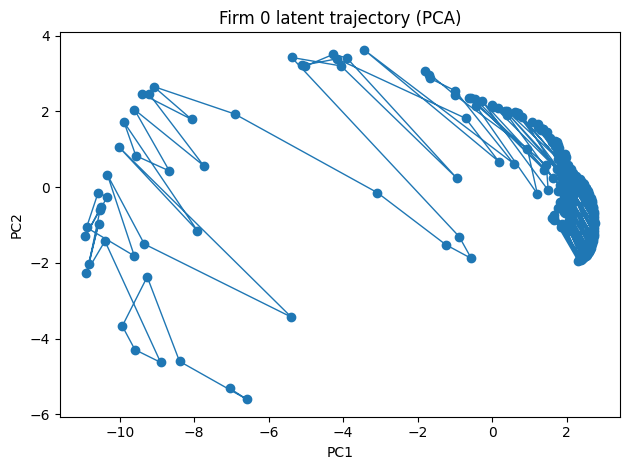

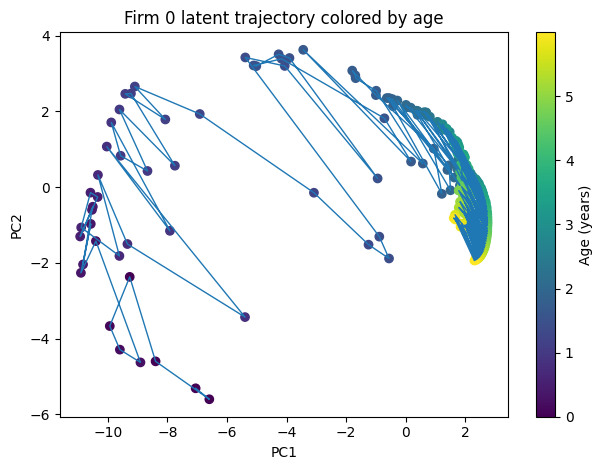

In [14]:
# Plot one firm's latent trajectory in 2D (PCA)
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(X)

plt.figure()
plt.plot(Z[:,0], Z[:,1], marker="o", linewidth=1)
plt.title(f"Firm {FIRM_ID} latent trajectory (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Color by time
plt.figure()
sc = plt.scatter(Z[:,0], Z[:,1], c=t_years)
plt.plot(Z[:,0], Z[:,1], linewidth=1)
plt.title(f"Firm {FIRM_ID} latent trajectory colored by age")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(sc, label="Age (years)")
plt.tight_layout()
plt.show()

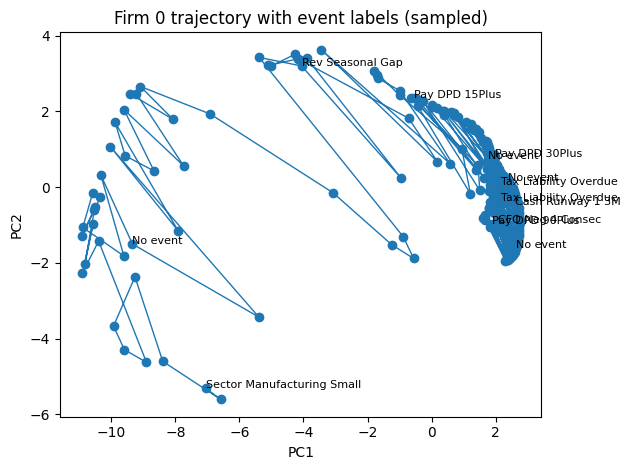

In [15]:
# Annotate a few points with exact label names
step = max(1, len(df_firm)//12)
plt.figure()
plt.plot(Z[:,0], Z[:,1], marker="o", linewidth=1)
for i in range(0, len(df_firm), step):
    tid = int(df_firm.iloc[i].token_id)
    name = id_to_name.get(tid, str(tid))
    plt.text(Z[i,0], Z[i,1], name, fontsize=8)
plt.title(f"Firm {FIRM_ID} trajectory with event labels (sampled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## Cohort view: last latent state per firm

We compute the **last hidden state** for a sample of firms and project to 2D.
Optionally color by whether the firm experiences an exit event.


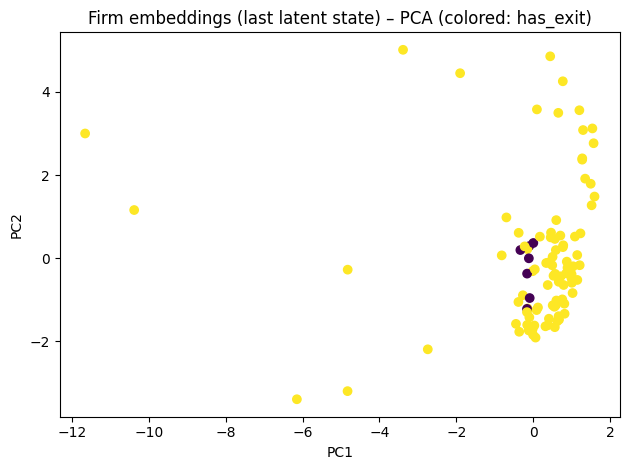

In [16]:
# Helper: check if firm has an exit token
exit_ids = set(vocab[vocab["code"].astype(str).str.startswith("EXIT_")]["index"].astype(int).tolist())

def firm_has_exit(df_firm):
    return any(int(t) in exit_ids for t in df_firm.token_id.values)

# Sample firms for speed
rng = np.random.default_rng(0)
sample_n = 100
sample_firms = rng.choice(firm_ids.astype(int), size=min(sample_n, len(firm_ids)), replace=False)

last_states = []
has_exit = []

for fid in sample_firms:
    df_f, idx_f, age_f = get_firm_events(events, int(fid))
    Xf = run_and_get_latents(idx_f, age_f)
    last_states.append(Xf[-1])
    has_exit.append(firm_has_exit(df_f))

last_states = np.stack(last_states, axis=0)
Zc = PCA(n_components=2, random_state=0).fit_transform(last_states)

plt.figure()
plt.scatter(Zc[:,0], Zc[:,1], c=np.array(has_exit, dtype=int))
plt.title("Firm embeddings (last latent state) – PCA (colored: has_exit)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [17]:
# Cleanup hook
handle.remove()
print("Done.")

Done.
